# Report LLM_Benchmark

## Introduction
The main goal of this project is to provide a general benchmark to evaluate different LLMs performances under different types of planning domains to better understand in advance what fre the planning capabilities of a given LLM.
In the repository the material developed by other students could be found as well as the folder containing 20 planning domains among the most important ones used at world level PDDL conferences.

## About the PDDL Domains
In order to obtain a better classification 

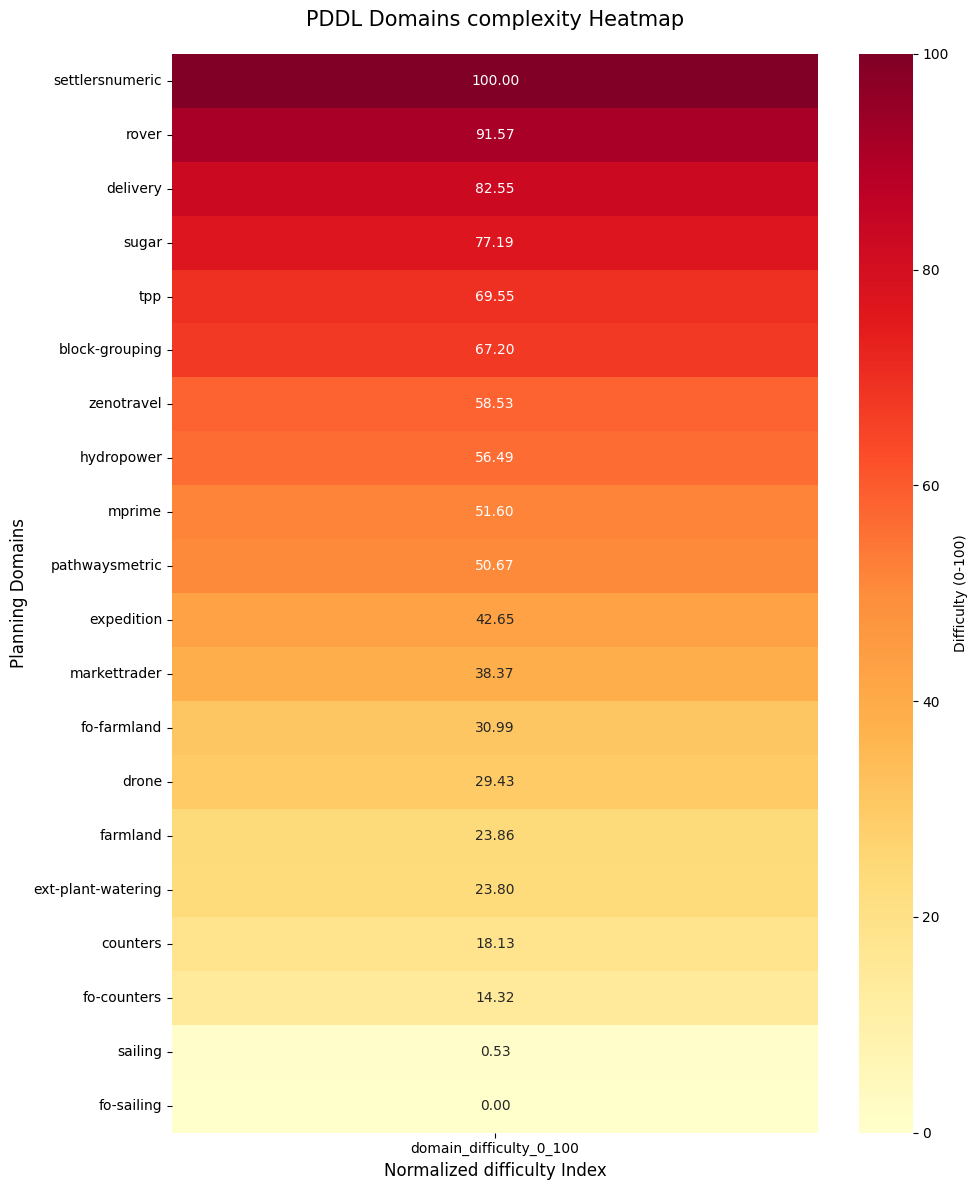

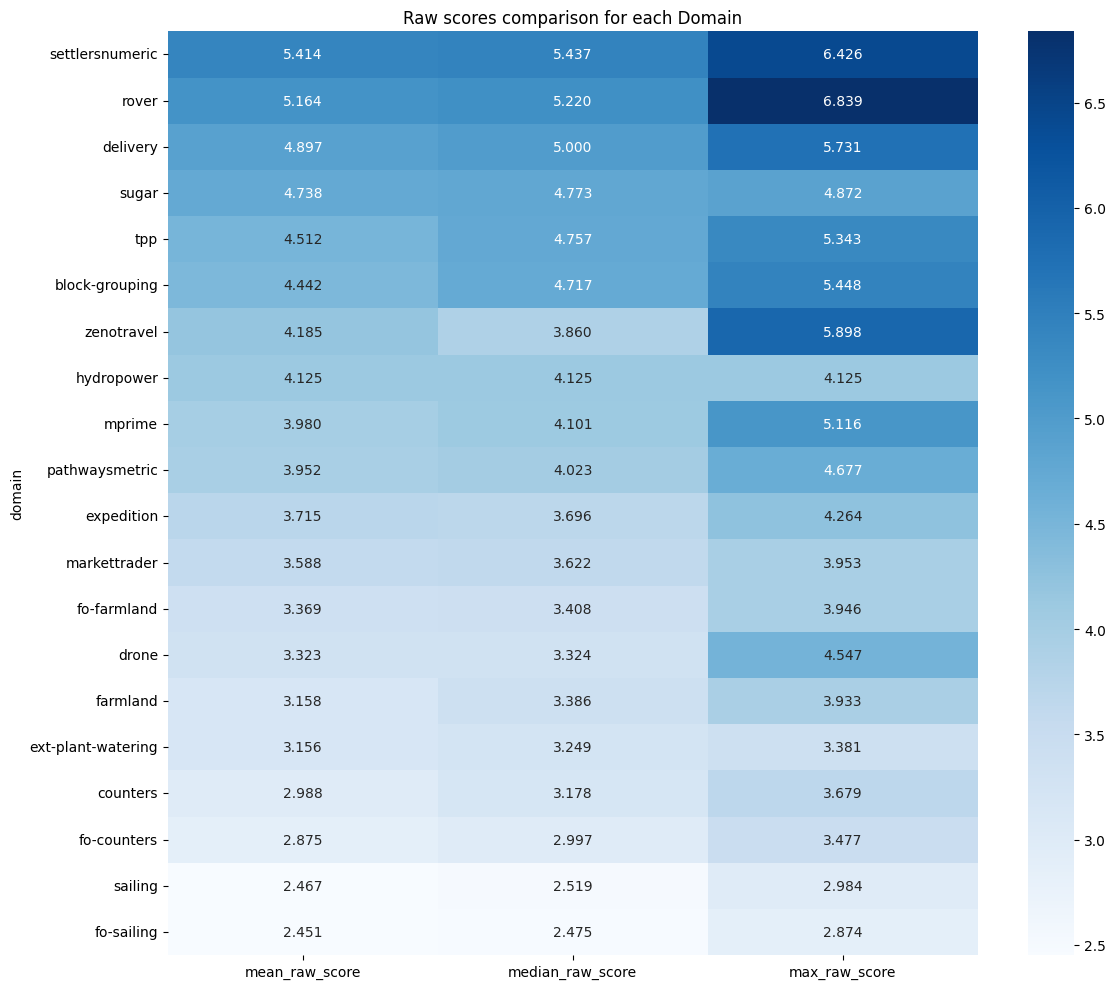

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Configurazione dei percorsi
# Partendo da analysis/notebooks, risaliamo di due livelli per trovare domains_complexity
base_path = Path.cwd().parent.parent
summary_file = base_path / "domains_complexity" / "domain_summary.csv"

# 2. Caricamento dei dati
if not summary_file.exists():
    print(f"Errore: Il file {summary_file} non esiste. Esegui prima lo script score_domains_complexity.py")
else:
    df = pd.read_csv(summary_file)

    # 3. Preparazione dei dati per la heatmap
    # Selezioniamo il dominio come indice e la colonna della difficoltà 0-100
    # Ordiniamo per difficoltà decrescente per una visualizzazione migliore
    heatmap_data = df.set_index('domain')[['domain_difficulty_0_100']].sort_values(by='domain_difficulty_0_100', ascending=False)

    # 4. Creazione della Heatmap
    plt.figure(figsize=(10, 12))
    
    # annot=True inserisce il valore numerico nelle celle
    # cmap="YlOrRd" usa una scala dal giallo (facile) al rosso (difficile)
    sns.heatmap(heatmap_data, annot=True, cmap="YlOrRd", fmt=".2f", cbar_kws={'label': 'Difficulty (0-100)'})

    plt.title('PDDL Domains complexity Heatmap', fontsize=15, pad=20)
    plt.ylabel('Planning Domains', fontsize=12)
    plt.xlabel('Normalized difficulty Index', fontsize=12)
    
    # Ottimizzazione del layout
    plt.tight_layout()
    plt.show()

    # Opzionale: Heatmap comparativa con più metriche grezze
    # Se vuoi vedere anche come si relazionano media e mediana raw:
    plt.figure(figsize=(12, 10))
    metrics_cols = ['mean_raw_score', 'median_raw_score', 'max_raw_score']
    comparative_data = df.set_index('domain')[metrics_cols].sort_values(by='mean_raw_score', ascending=False)
    
    sns.heatmap(comparative_data, annot=True, cmap="Blues", fmt=".3f")
    plt.title('Raw scores comparison for each Domain')
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

def create_raw_score_heatmap():
    """
    Genera una heatmap dei raw scores per domini specifici.

    Legge i dati da 'complexity_scores.csv', filtra per i domini di interesse,
    e crea una heatmap che mostra i raw_score per ogni istanza (pfile).
    """
    # Definisci i domini da visualizzare
    domains_to_plot = [
        'settlersnumeric',
        'rover',
        'fo-sailing',
        'fo-counters',
        'expedition',
        'block-grouping'
    ]

    # Percorso del file CSV. Si assume che lo script sia eseguito dalla root del repo.
    csv_path = Path('Benchmark_Framework/domains_complexity/complexity_scores.csv')

    if not csv_path.exists():
        print(f"File non trovato: {csv_path}")
        print("Assicurati di eseguire lo script dalla cartella radice 'LLM_Benchmark' e che il file 'complexity_scores.csv' esista.")
        print("Potrebbe essere necessario eseguire prima lo script 'score_domains_complexity.py'.")
        return

    # Carica i dati
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"Errore nel caricamento del file CSV: {e}")
        return

    # Filtra per i domini di interesse
    df_filtered = df[df['domain'].isin(domains_to_plot)].copy()

    if df_filtered.empty:
        print("Nessun dato trovato per i domini specificati.")
        print(f"Domini richiesti: {domains_to_plot}")
        print(f"Domini disponibili nel file: {df['domain'].unique().tolist()}")
        return

    # Estrai il numero dall'istanza per un ordinamento corretto
    df_filtered['instance_num'] = df_filtered['instance'].str.extract(r'(\d+)').astype(int)

    # Pivot della tabella per creare la matrice per la heatmap
    heatmap_data = df_filtered.pivot_table(
        index='domain',
        columns='instance_num',
        values='raw_score'
    )

    # Ordina le colonne (istanze) in modo numerico
    heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)
    
    # Rinomina le colonne per includere 'pfile'
    heatmap_data.columns = [f'pfile{col}' for col in heatmap_data.columns]

    # Ordina le righe (domini) in base alla lista fornita per coerenza
    heatmap_data = heatmap_data.reindex(domains_to_plot)

    # Crea la heatmap
    plt.figure(figsize=(20, 8))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="Purples",
        linewidths=.5,
        cbar_kws={'label': 'Raw Score'}
    )

    # Aggiungi titoli e label
    plt.title('Heatmap dei Raw Scores per Istanza e Dominio', fontsize=16)
    plt.xlabel('Istanza (pfile)', fontsize=12)
    plt.ylabel('Dominio', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Salva e mostra la figura
    output_path = Path('Benchmark_Framework/analysis/reports/raw_scores_heatmap.png')
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path)
    print(f"Heatmap salvata in: {output_path}")
    plt.show()

if __name__ == '__main__':
    create_raw_score_heatmap()

: 